# Benchmark Results — LLM Comparison

Visualizes benchmark suite results from `benchmark.py` runs, comparing models on cost, speed, token usage, retries, and lab quality metrics.

In [20]:
import json
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import MaxNLocator

BENCHMARK_DIR = Path("../../Artifacts/Data/Benchmark")

# Load the most recent suite_results file
suite_files = sorted(BENCHMARK_DIR.glob("suite_results_*.json"))
if not suite_files:
    raise FileNotFoundError(f"No suite_results_*.json found in {BENCHMARK_DIR}")

latest = suite_files[-1]
print(f"Loading: {latest.name}")
raw = json.loads(latest.read_text(encoding="utf-8"))

Loading: suite_results_20260409_110524.json


In [2]:
# Flatten nested JSON into a DataFrame
rows = []
for r in raw:
    tracking = r.get("tracking", {})
    tokens = tracking.get("tokens", {})
    retries = tracking.get("retries", {})
    errors = tracking.get("errors", {})
    cost = tracking.get("cost", {})
    lab = r.get("lab_metrics", {})

    rows.append({
        "Model": r.get("display_name", r.get("model", "?")),
        "Provider": r.get("provider", "?"),
        "Success": r.get("success", False),
        "Wall Time (s)": r.get("wall_time_seconds", 0),
        "Prompt Tokens": tokens.get("prompt", 0),
        "Completion Tokens": tokens.get("completion", 0),
        "Total Tokens": tokens.get("total", 0),
        "Cost ($)": cost.get("total_usd", 0),
        "Retries": retries.get("total", 0),
        "Parse Errors": errors.get("parse_errors", 0),
        "Objects": lab.get("num_objects", 0),
        "Clips": lab.get("num_clips", 0),
        "Components": lab.get("num_components", 0),
        "Object Changes": lab.get("num_object_changes", 0),
        "Unique Prefabs": lab.get("num_unique_prefabs", 0),
        "Text Labels": lab.get("num_text_labels", 0),
    })

df = pd.DataFrame(rows).set_index("Model")
df

,Provider,Success,Wall Time (s),Prompt Tokens,Completion Tokens,Total Tokens,Cost ($),Retries,Parse Errors,Objects,Clips,Components,Object Changes,Unique Prefabs,Text Labels
Model,,,,,,,,,,,,,,,
GPT-4o Mini,openai,False,61.84,28825,3353,32178,0.006336,5,3,0,0,0,0,0,0
Claude Haiku 4.5,anthropic,True,16.60,5841,3227,9068,0.017581,0,0,9,6,15,20,8,2
Gemini 2.5 Flash Lite,google,True,9.98,358,3558,3916,0.001094,0,0,10,6,18,22,3,9
GPT-4o Mini,openai,False,44.78,13882,1963,15845,0.003260,5,3,0,0,0,0,0,0
Claude Haiku 4.5,anthropic,True,13.76,5843,2378,8221,0.014186,0,0,9,7,2,17,5,1
Gemini 2.5 Flash Lite,google,True,13.04,359,4299,4658,0.001317,0,0,16,9,15,30,5,5
GPT-4o Mini,openai,False,41.99,17439,2112,19551,0.003883,5,3,0,0,0,0,0,0
Claude Haiku 4.5,anthropic,True,17.56,5843,3349,9192,0.018070,0,0,7,7,7,25,7,7
Gemini 2.5 Flash Lite,google,True,7.98,359,3010,3369,0.000930,0,0,7,7,7,24,4,4


## Summary Table

In [3]:
summary_cols = ["Provider", "Success", "Wall Time (s)", "Total Tokens", "Cost ($)", "Retries", "Parse Errors"]
summary = df[summary_cols].copy()
summary["Cost ($)"] = summary["Cost ($)"].map("${:.6f}".format)
summary["Wall Time (s)"] = summary["Wall Time (s)"].map("{:.1f}".format)
summary.style.map(
    lambda v: "background-color: #d4edda" if v is True else ("background-color: #f8d7da" if v is False else ""),
    subset=["Success"]
)

KeyError: '`Styler.apply` and `.map` are not compatible with non-unique index or columns.'

In [39]:
import matplotlib as mpl

# --- Readability settings for LaTeX export ---
mpl.rcParams.update({
    "figure.figsize":   (20, 7),       # wider, taller figure
    "figure.dpi":       150,            # sharper on screen; use 300 for print
    "font.size":        15,             # base font size (scales most text)
    "axes.titlesize":   20,             # subplot titles
    "axes.labelsize":   18,             # x/y axis labels
    "xtick.labelsize":  15,             # tick labels
    "ytick.labelsize":  15,
    "axes.titlepad":    15,             # breathing room above titles
    "axes.spines.top":  False,          # cleaner look — drop top/right borders
    "axes.spines.right":False,
})

from matplotlib.ticker import MaxNLocator

## Cost & Speed Comparison

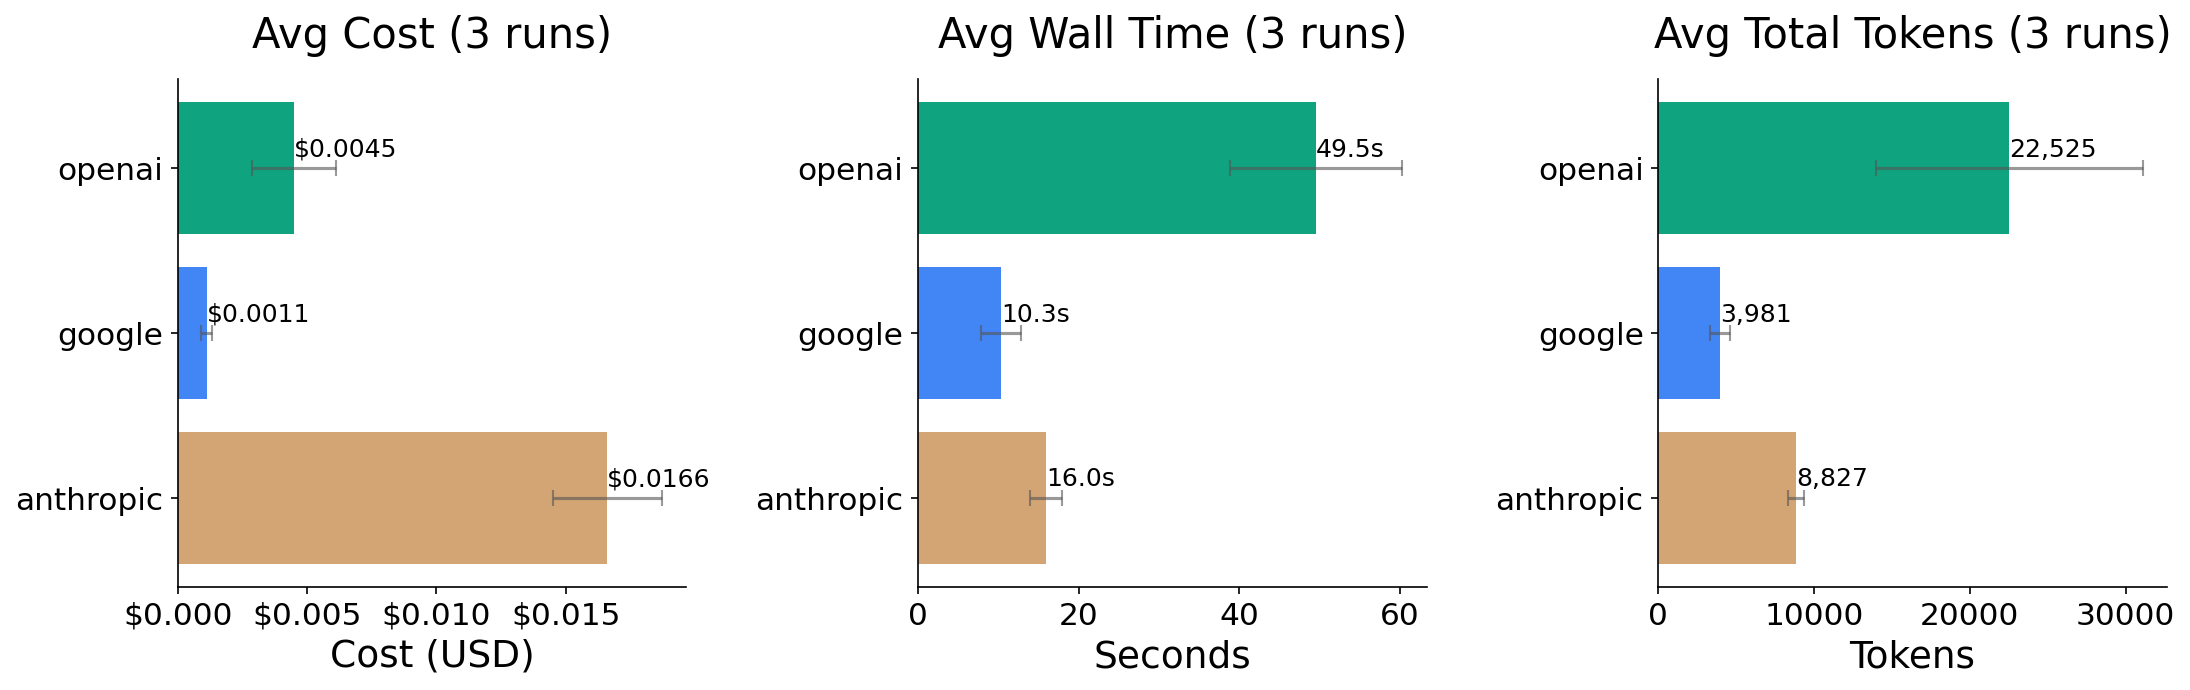

In [33]:
# Aggregate: average the 3 runs per provider
df_agg = df.groupby("Provider").agg(
    Cost=("Cost ($)", "mean"),
    WallTime=("Wall Time (s)", "mean"),
    Tokens=("Total Tokens", "mean"),
).reset_index()

# Optional: also compute std for error bars
df_std = df.groupby("Provider").agg(
    Cost_std=("Cost ($)", "std"),
    WallTime_std=("Wall Time (s)", "std"),
    Tokens_std=("Total Tokens", "std"),
).reset_index()

df_agg = df_agg.merge(df_std, on="Provider")

PROVIDER_COLORS = {"openai": "#10a37f", "anthropic": "#d4a574", "google": "#4285f4"}
colors = [PROVIDER_COLORS.get(p, "#999") for p in df_agg["Provider"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def annotate_bars(ax, bars, values, stds, fmt_fn):
    for bar, v, std in zip(bars, values, stds):
        x = v #+ std  # tip of the error bar
        y = bar.get_y() + 0.55*bar.get_height()  # top edge of the bar
        ax.text(x, y, fmt_fn(v),
                va="bottom", ha="left", fontsize=12)

# Cost
ax = axes[0]
bars = ax.barh(df_agg["Provider"], df_agg["Cost"], color=colors,
               xerr=df_agg["Cost_std"], capsize=4, error_kw={"ecolor": "#555", "alpha": 0.6})
ax.set_xlabel("Cost (USD)")
ax.set_title("Avg Cost (3 runs)")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("$%.3f"))
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))   # <-- add this line
annotate_bars(ax, bars, df_agg["Cost"], df_agg["Cost_std"], lambda v: f"${v:.4f}")

# Wall time
ax = axes[1]
bars = ax.barh(df_agg["Provider"], df_agg["WallTime"], color=colors,
               xerr=df_agg["WallTime_std"], capsize=4, error_kw={"ecolor": "#555", "alpha": 0.6})
ax.set_xlabel("Seconds")
ax.set_title("Avg Wall Time (3 runs)")
annotate_bars(ax, bars, df_agg["WallTime"], df_agg["WallTime_std"], lambda v: f"{v:.1f}s")
# Total tokens
ax = axes[2]
bars = ax.barh(df_agg["Provider"], df_agg["Tokens"], color=colors,
               xerr=df_agg["Tokens_std"], capsize=4, error_kw={"ecolor": "#555", "alpha": 0.6})
ax.set_xlabel("Tokens")
ax.set_title("Avg Total Tokens (3 runs)")
annotate_bars(ax, bars, df_agg["Tokens"], df_agg["Tokens_std"], lambda v: f"{v:,.0f}")

plt.tight_layout()
plt.show()

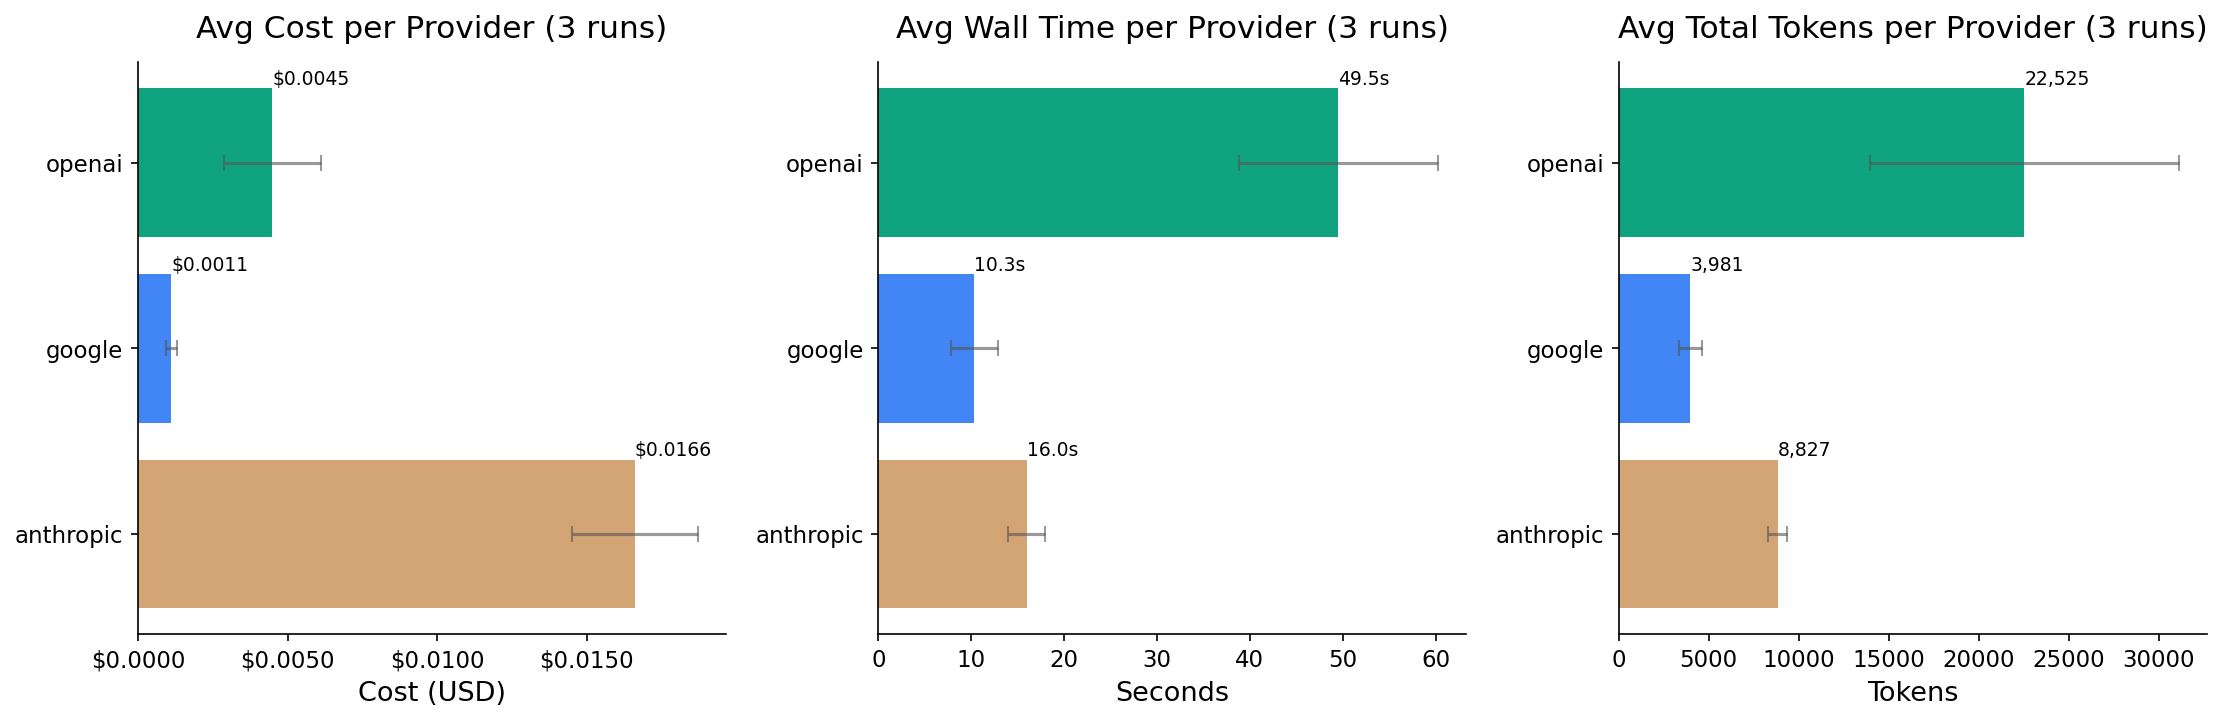

In [6]:
# Aggregate: average the 3 runs per provider
df_agg = df.groupby("Provider").agg(
    Cost=("Cost ($)", "mean"),
    WallTime=("Wall Time (s)", "mean"),
    Tokens=("Total Tokens", "mean"),
).reset_index()

# Optional: also compute std for error bars
df_std = df.groupby("Provider").agg(
    Cost_std=("Cost ($)", "std"),
    WallTime_std=("Wall Time (s)", "std"),
    Tokens_std=("Total Tokens", "std"),
).reset_index()

df_agg = df_agg.merge(df_std, on="Provider")

PROVIDER_COLORS = {"openai": "#10a37f", "anthropic": "#d4a574", "google": "#4285f4"}
colors = [PROVIDER_COLORS.get(p, "#999") for p in df_agg["Provider"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def annotate_bars(ax, bars, values, stds, fmt_fn, max_val):
    for bar, v, std in zip(bars, values, stds):
        x = v  # tip of the error bar
        y = bar.get_y() + bar.get_height()  # top edge of the bar
        ax.text(x, y, fmt_fn(v),
                va="bottom", ha="left", fontsize=9)

# Cost
ax = axes[0]
bars = ax.barh(df_agg["Provider"], df_agg["Cost"], color=colors,
               xerr=df_agg["Cost_std"], capsize=4, error_kw={"ecolor": "#555", "alpha": 0.6})
ax.set_xlabel("Cost (USD)")
ax.set_title("Avg Cost per Provider (3 runs)")
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("$%.4f"))
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
annotate_bars(ax, bars, df_agg["Cost"], df_agg["Cost_std"], lambda v: f"${v:.4f}", df_agg["Cost"].max())

# Wall time
ax = axes[1]
bars = ax.barh(df_agg["Provider"], df_agg["WallTime"], color=colors,
               xerr=df_agg["WallTime_std"], capsize=4, error_kw={"ecolor": "#555", "alpha": 0.6})
ax.set_xlabel("Seconds")
ax.set_title("Avg Wall Time per Provider (3 runs)")
annotate_bars(ax, bars, df_agg["WallTime"], df_agg["WallTime_std"], lambda v: f"{v:.1f}s", df_agg["WallTime"].max())

# Total tokens
ax = axes[2]
bars = ax.barh(df_agg["Provider"], df_agg["Tokens"], color=colors,
               xerr=df_agg["Tokens_std"], capsize=4, error_kw={"ecolor": "#555", "alpha": 0.6})
ax.set_xlabel("Tokens")
ax.set_title("Avg Total Tokens per Provider (3 runs)")
annotate_bars(ax, bars, df_agg["Tokens"], df_agg["Tokens_std"], lambda v: f"{v:,.0f}", df_agg["Tokens"].max())

plt.tight_layout()
plt.show()

## Token Breakdown (Prompt vs Completion)

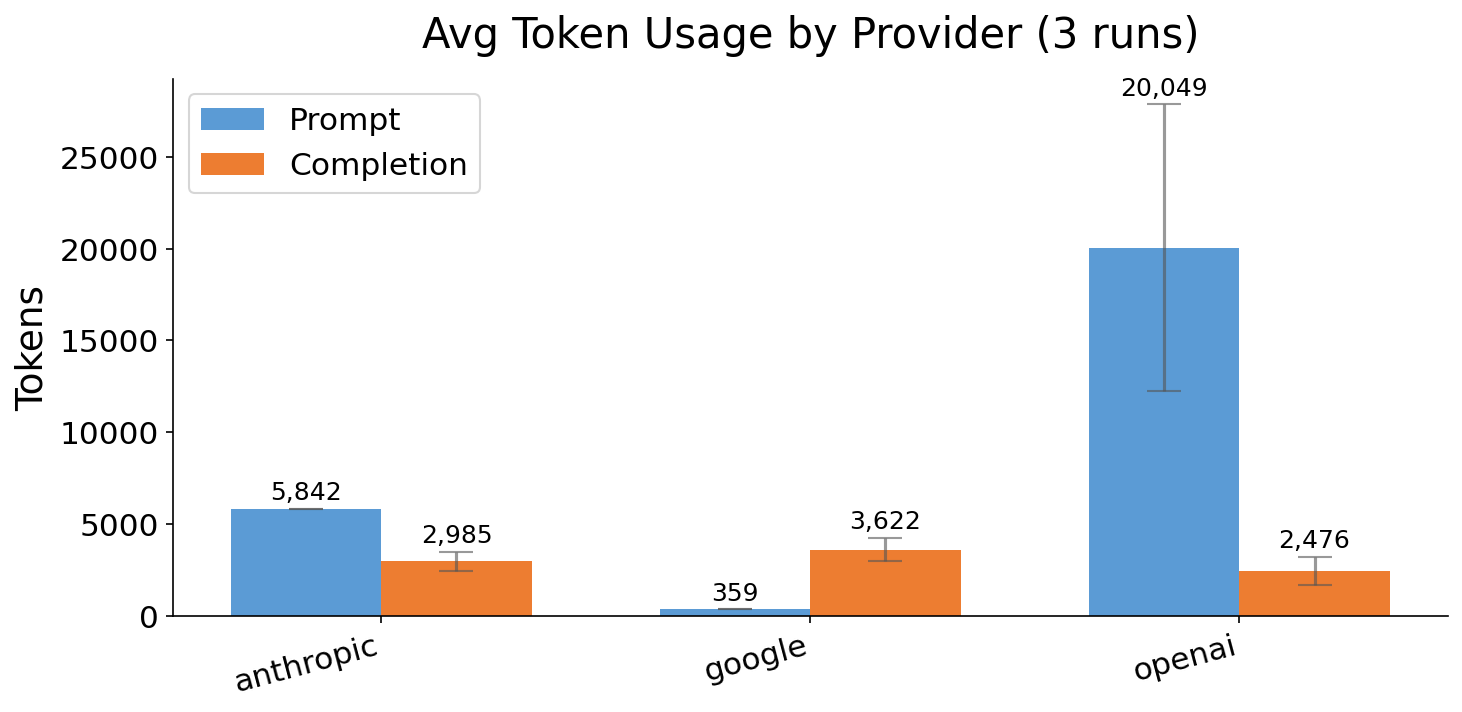

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

providers = df_agg["Provider"].tolist()
x = range(len(providers))
width = 0.35

# Aggregate prompt/completion tokens separately
df_tokens = df.groupby("Provider").agg(
    Prompt=("Prompt Tokens", "mean"),
    Completion=("Completion Tokens", "mean"),
    Prompt_std=("Prompt Tokens", "std"),
    Completion_std=("Completion Tokens", "std"),
).reset_index()

colors_map = [PROVIDER_COLORS.get(p, "#999") for p in df_tokens["Provider"]]

bars1 = ax.bar([i - width/2 for i in x], df_tokens["Prompt"], width,
               yerr=df_tokens["Prompt_std"], capsize=8,
               label="Prompt", color="#5b9bd5",
               error_kw={"ecolor": "#555", "alpha": 0.6})
bars2 = ax.bar([i + width/2 for i in x], df_tokens["Completion"], width,
               yerr=df_tokens["Completion_std"], capsize=8,
               label="Completion", color="#ed7d31",
               error_kw={"ecolor": "#555", "alpha": 0.6})

ax.set_ylabel("Tokens")
ax.set_title("Avg Token Usage by Provider (3 runs)")
ax.set_xticks(list(x))
ax.set_xticklabels(providers, rotation=15, ha="right")
ax.legend()
ax.bar_label(bars1, fmt="{:,.0f}", fontsize=12, padding=2)
ax.bar_label(bars2, fmt="{:,.0f}", fontsize=12, padding=2)

plt.tight_layout()
plt.show()

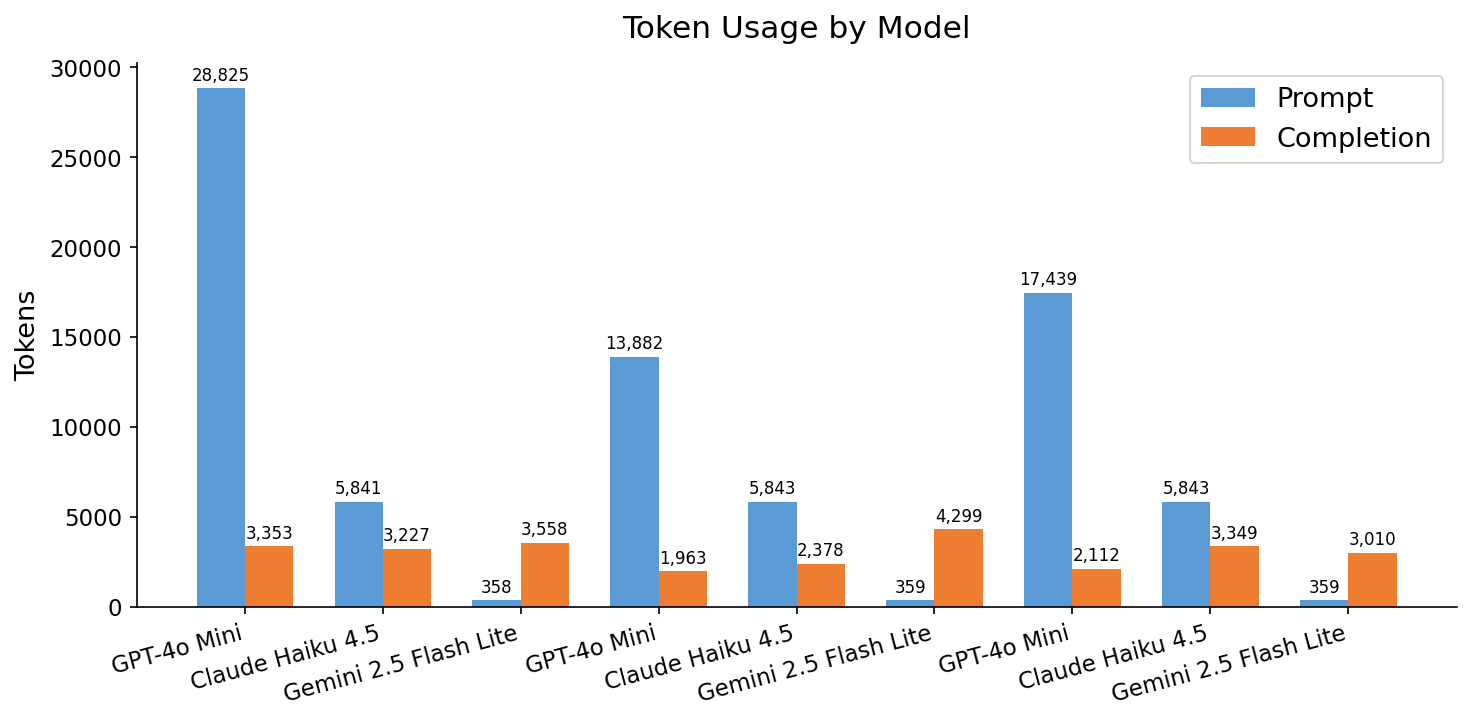

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

models = df.index.tolist()
x = range(len(models))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df["Prompt Tokens"], width, label="Prompt", color="#5b9bd5")
bars2 = ax.bar([i + width/2 for i in x], df["Completion Tokens"], width, label="Completion", color="#ed7d31")

ax.set_ylabel("Tokens")
ax.set_title("Token Usage by Model")
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()
ax.bar_label(bars1, fmt="{:,.0f}", fontsize=8, padding=2)
ax.bar_label(bars2, fmt="{:,.0f}", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## Retries & Errors

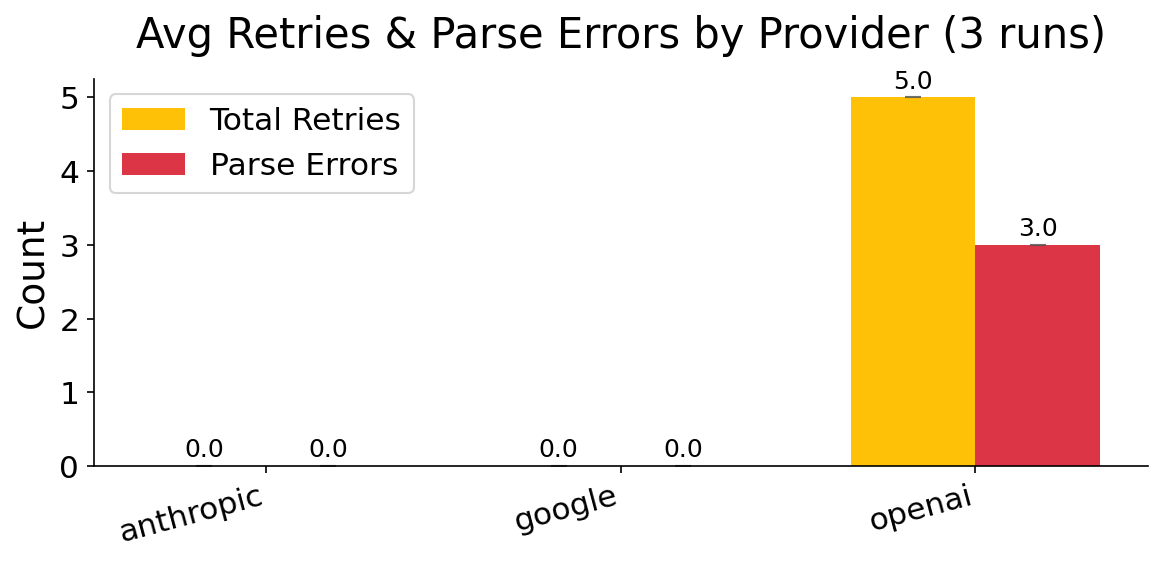

In [41]:
fig, ax = plt.subplots(figsize=(8, 4))

df_errors = df.groupby("Provider").agg(
    Retries=("Retries", "mean"),
    ParseErrors=("Parse Errors", "mean"),
    Retries_std=("Retries", "std"),
    ParseErrors_std=("Parse Errors", "std"),
).reset_index()

providers = df_errors["Provider"].tolist()
x = range(len(providers))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_errors["Retries"], width,
               yerr=df_errors["Retries_std"], capsize=4,
               label="Total Retries", color="#ffc107",
               error_kw={"ecolor": "#555", "alpha": 0.6})
bars2 = ax.bar([i + width/2 for i in x], df_errors["ParseErrors"], width,
               yerr=df_errors["ParseErrors_std"], capsize=4,
               label="Parse Errors", color="#dc3545",
               error_kw={"ecolor": "#555", "alpha": 0.6})

ax.set_ylabel("Count")
ax.set_title("Avg Retries & Parse Errors by Provider (3 runs)")
ax.set_xticks(list(x))
ax.set_xticklabels(providers, rotation=15, ha="right")
ax.legend()
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.bar_label(bars1, fmt="{:.1f}", fontsize=12, padding=2)
ax.bar_label(bars2, fmt="{:.1f}", fontsize=12, padding=2)

plt.tight_layout()
plt.show()

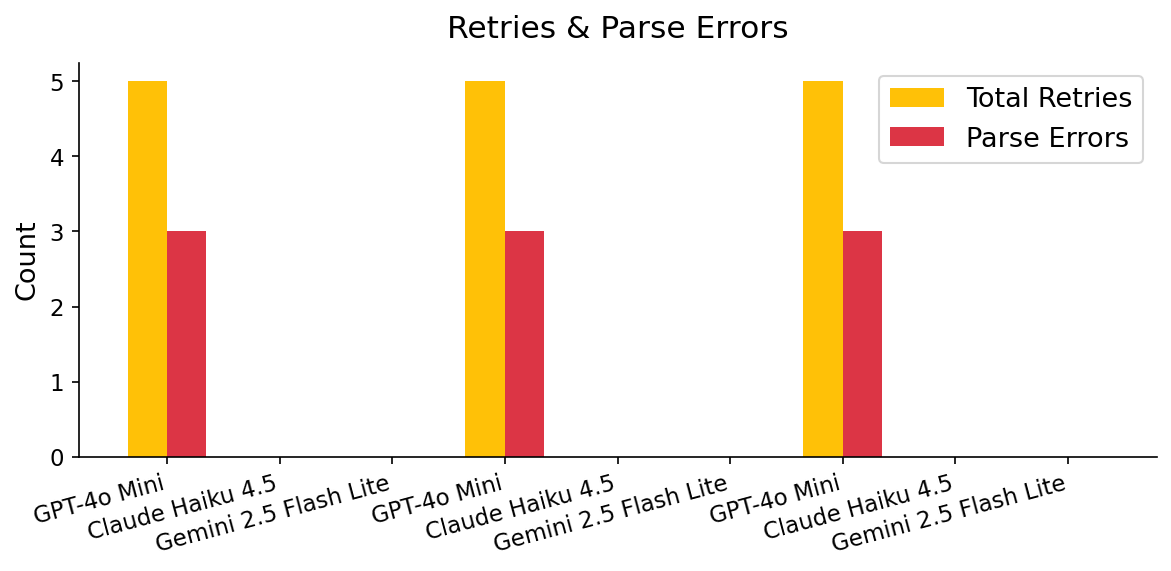

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(models))
width = 0.35

ax.bar([i - width/2 for i in x], df["Retries"], width, label="Total Retries", color="#ffc107")
ax.bar([i + width/2 for i in x], df["Parse Errors"], width, label="Parse Errors", color="#dc3545")

ax.set_ylabel("Count")
ax.set_title("Retries & Parse Errors")
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## Lab Quality Metrics (Successful Runs Only)

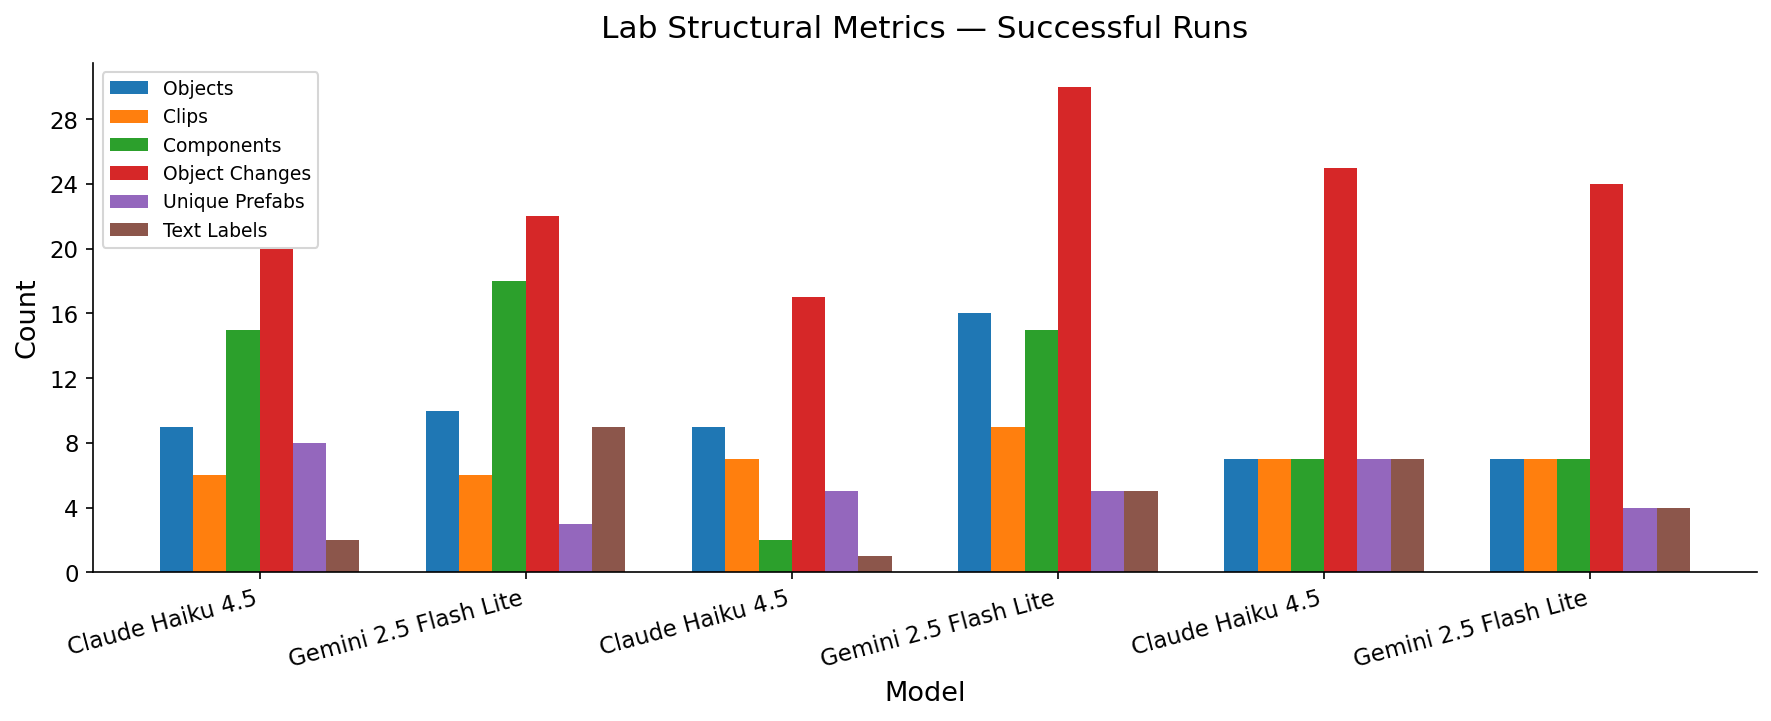

In [9]:
ok = df[df["Success"] == True].copy()

if ok.empty:
    print("No successful runs to compare.")
else:
    quality_cols = ["Objects", "Clips", "Components", "Object Changes", "Unique Prefabs", "Text Labels"]
    ok_quality = ok[quality_cols]

    fig, ax = plt.subplots(figsize=(12, 5))
    ok_quality.plot(kind="bar", ax=ax, width=0.75)
    ax.set_title("Lab Structural Metrics — Successful Runs")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ok.index, rotation=15, ha="right")
    ax.legend(loc="upper left", fontsize=9)
    ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # Quality summary table
    ok_quality

## Efficiency: Cost per Lab Element

In [10]:
if not ok.empty:
    efficiency = pd.DataFrame(index=ok.index)
    total_elements = ok["Objects"] + ok["Clips"] + ok["Components"]
    efficiency["Total Elements"] = total_elements
    efficiency["Cost ($)"] = ok["Cost ($)"]
    efficiency["$ / Element"] = (ok["Cost ($)"] / total_elements.replace(0, float("nan")))
    efficiency["Tokens / Element"] = (ok["Total Tokens"] / total_elements.replace(0, float("nan"))).round(0).astype(int)
    efficiency["Seconds / Element"] = (ok["Wall Time (s)"] / total_elements.replace(0, float("nan"))).round(2)
    efficiency